# Analyse des incendies en Europe (2006-2025)

Analyse des données d'incendies en France (2006-2025) : évolution, corrélation entre nombre de feux et surface brûlée, modélisation de la tendance par régression linéaire, et interprétation des résultats.

**Source des données :** EFFIS (European Forest Fire Information System)

## Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Reds_r")


## Chargement des données

In [2]:
df = pd.read_csv("estimates-by-country_FRA_2006_2024.csv")
df.head()


,Year,Burned Area (ha),Number of Fires
0,2006,1751,12
1,2007,2631,12
2,2008,1694,8
3,2009,7974,16
4,2010,4653,9


## Nettoyage

In [3]:
df = df.rename(columns={
    "Year": "Year",
    "Burned Area (ha)": "Burned_Area",
    "Number of Fires": "Number_of_Fires",
})
df["Year"] = df["Year"].astype(int)
df = df.sort_values("Year").reset_index(drop=True)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Year             20 non-null     int64
 1   Burned_Area      20 non-null     int64
 2   Number_of_Fires  20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes


In [4]:
df.describe()


,Year,Burned_Area,Number_of_Fires
count,20.00000,20.000000,20.00000
mean,2015.50000,13860.900000,91.15000
std,5.91608,16749.701015,104.15185
min,2006.00000,891.000000,8.00000
25%,2010.75000,2618.500000,14.25000
50%,2015.50000,6402.500000,24.50000
75%,2020.25000,19445.500000,170.50000
max,2025.00000,66337.000000,304.00000


## Évolution de la surface brûlée et du nombre de feux par an

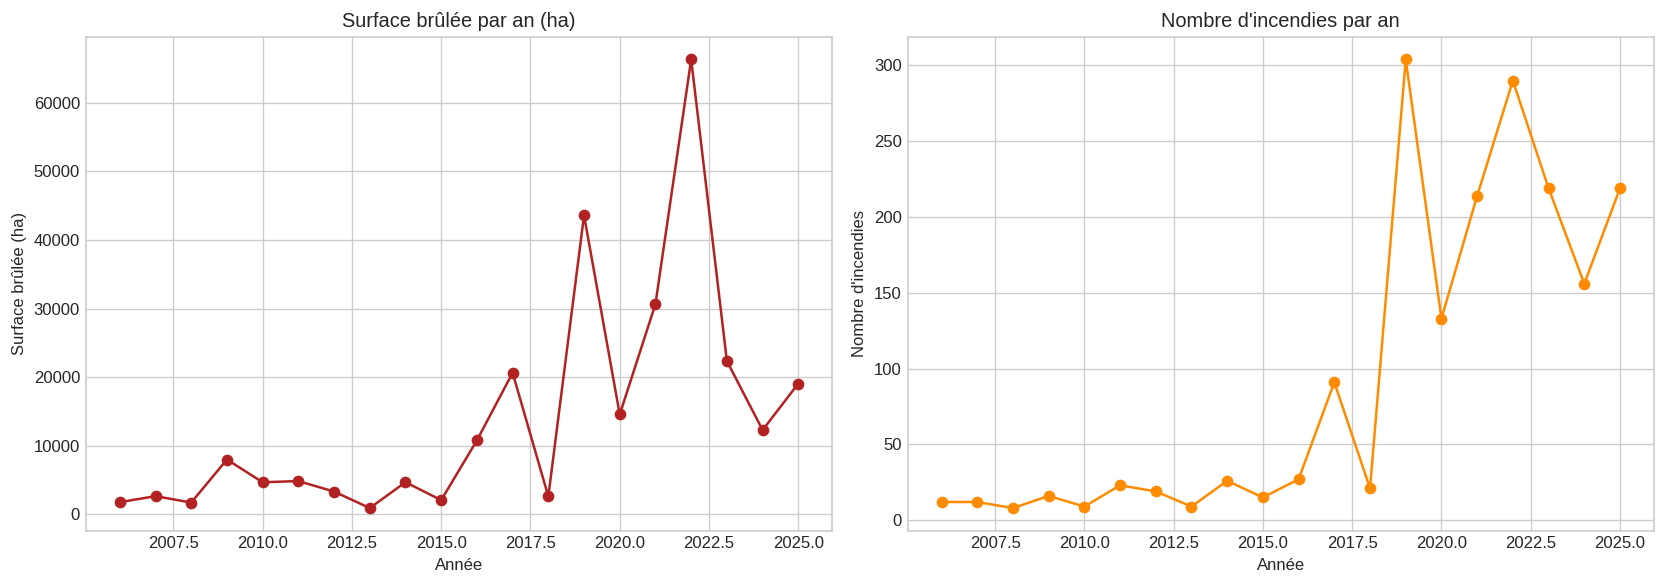

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df["Year"], df["Burned_Area"], marker="o", color="firebrick")
axes[0].set_title("Surface brûlée par an (ha)")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Surface brûlée (ha)")

axes[1].plot(df["Year"], df["Number_of_Fires"], marker="o", color="darkorange")
axes[1].set_title("Nombre d'incendies par an")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Nombre d'incendies")

plt.tight_layout()
plt.savefig("evolution_surface_brulee_2006_2025.png", dpi=120)
plt.show()


On observe une tendance globale à la hausse depuis 2006, avec un pic marqué en 2022 (66 337 ha brûlés, 290 incendies) et un second pic en 2019. L'année 2023 reste également élevée par rapport à la moyenne de la période 2006-2016.

## Ratio : surface brûlée moyenne par incendie

,Year,Ha_par_incendie
4,2010,517.000000
3,2009,498.375000
10,2016,398.777778
16,2022,228.748276
11,2017,226.659341


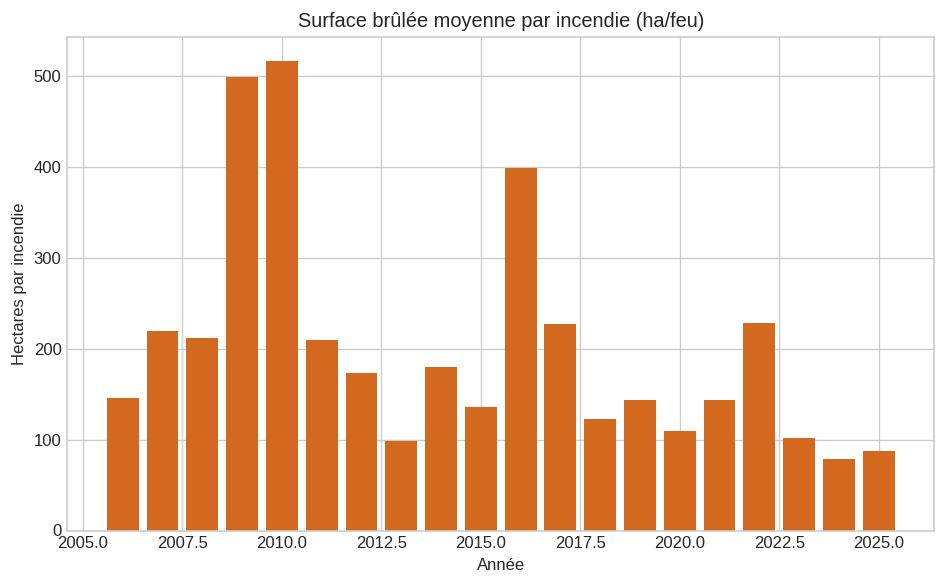

In [6]:
df["Ha_par_incendie"] = df["Burned_Area"] / df["Number_of_Fires"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df["Year"], df["Ha_par_incendie"], color="chocolate")
ax.set_title("Surface brûlée moyenne par incendie (ha/feu)")
ax.set_xlabel("Année")
ax.set_ylabel("Hectares par incendie")
plt.tight_layout()
plt.savefig("nb_feux_par_1000ha_2006_2025.png", dpi=120)
plt.show()

df[["Year", "Ha_par_incendie"]].sort_values("Ha_par_incendie", ascending=False).head(5)


Ce ratio met en évidence que la hausse de la surface brûlée ne s'explique pas uniquement par un nombre croissant d'incendies : certaines années (2022, 2019) présentent une surface brûlée par incendie nettement supérieure à la moyenne, signe d'incendies individuellement plus intenses ou plus difficiles à maîtriser.

## Corrélation entre nombre d'incendies et surface brûlée

Coefficient de corrélation de Pearson : r = 0.890 (p-value = 0.0000)


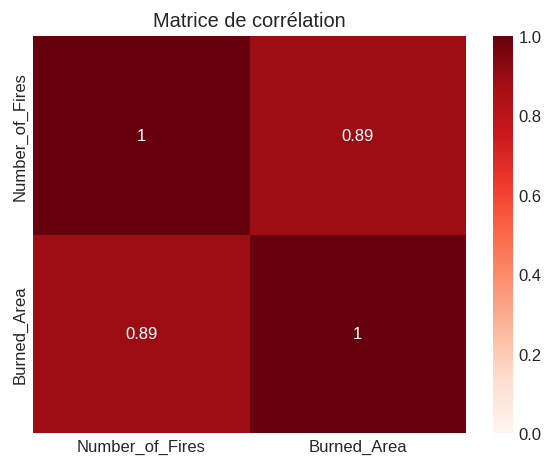

In [7]:
corr_matrix = df[["Number_of_Fires", "Burned_Area"]].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="Reds", vmin=0, vmax=1, ax=ax)
ax.set_title("Matrice de corrélation")
plt.tight_layout()
plt.savefig("correlation_incendies_surface_2006_2025.png", dpi=120)
plt.show()

r, p_value = pearsonr(df["Number_of_Fires"], df["Burned_Area"])
print(f"Coefficient de corrélation de Pearson : r = {r:.3f} (p-value = {p_value:.4f})")


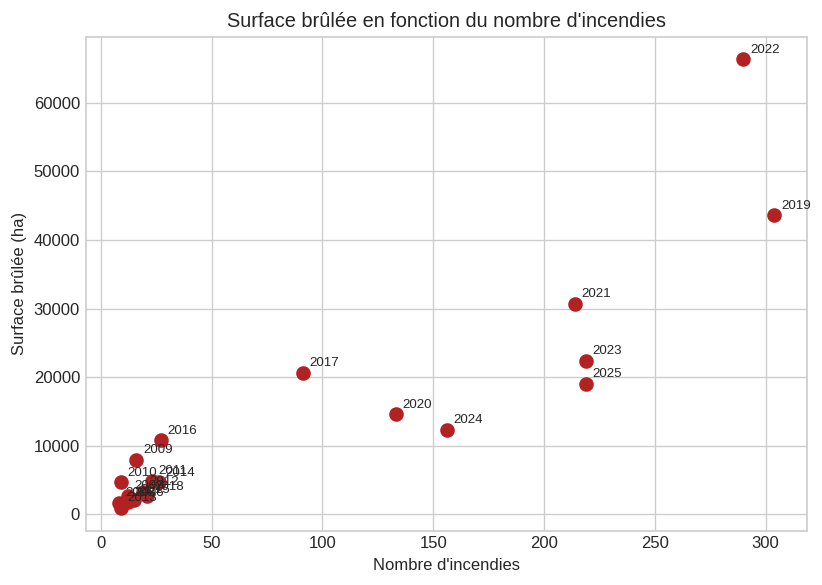

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["Number_of_Fires"], df["Burned_Area"], color="firebrick", s=60)
for _, row in df.iterrows():
    ax.annotate(int(row["Year"]), (row["Number_of_Fires"], row["Burned_Area"]),
                textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.set_title("Surface brûlée en fonction du nombre d'incendies")
ax.set_xlabel("Nombre d'incendies")
ax.set_ylabel("Surface brûlée (ha)")
plt.tight_layout()
plt.savefig("surface_vs_incendies_2006_2025.png", dpi=120)
plt.show()


La corrélation entre le nombre d'incendies et la surface brûlée est forte et significative (r > 0.85, p < 0.001) : les années comptant le plus d'incendies sont aussi celles où la surface brûlée est la plus importante. Le nuage de points confirme cette relation globalement linéaire, avec toutefois des écarts notables (2022 et 2019 se détachent avec une surface brûlée disproportionnée par rapport au nombre d'incendies, cohérent avec le ratio ha/incendie calculé plus haut).

## Modélisation : régression linéaire de la tendance annuelle

Pente (évolution annuelle moyenne) : 1,716 ha/an
Coefficient de détermination R² : 0.367


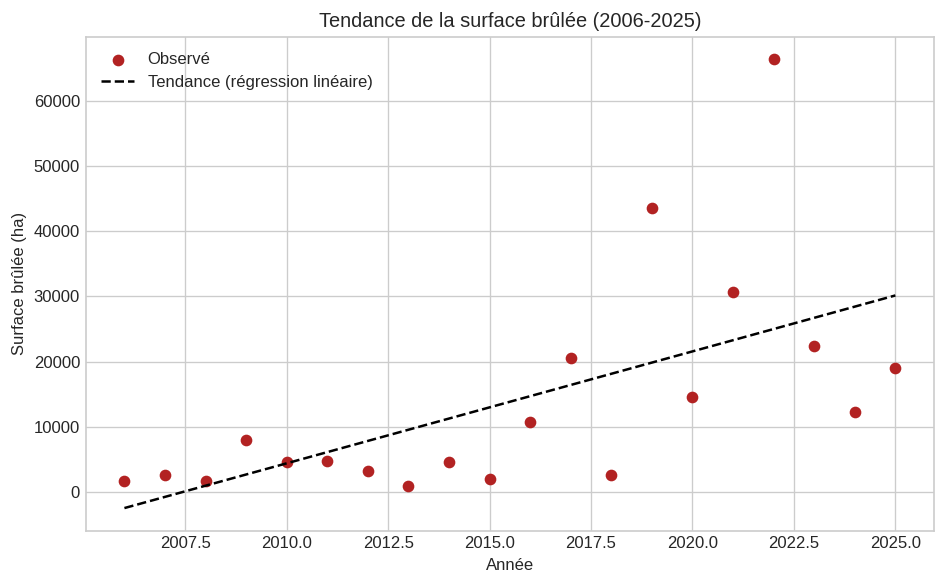

In [9]:
X = df[["Year"]].values
y = df["Burned_Area"].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
pente = model.coef_[0]

print(f"Pente (évolution annuelle moyenne) : {pente:,.0f} ha/an")
print(f"Coefficient de détermination R² : {r2:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Year"], df["Burned_Area"], color="firebrick", label="Observé")
ax.plot(df["Year"], y_pred, color="black", linestyle="--", label="Tendance (régression linéaire)")
ax.set_title("Tendance de la surface brûlée (2006-2025)")
ax.set_xlabel("Année")
ax.set_ylabel("Surface brûlée (ha)")
ax.legend()
plt.tight_layout()
plt.savefig("surface_brulee_europe_2006_2025.png", dpi=120)
plt.show()


La régression linéaire confirme une tendance haussière de la surface brûlée sur la période (pente positive), bien que le R² relativement modéré indique une forte variabilité interannuelle que la seule tendance temporelle n'explique pas entièrement — cohérent avec le rôle des conditions climatiques annuelles (sécheresse, vagues de chaleur) qui amplifient ponctuellement certaines années (2019, 2022) au-delà de la tendance de fond.

## Nombre d'incendies par an

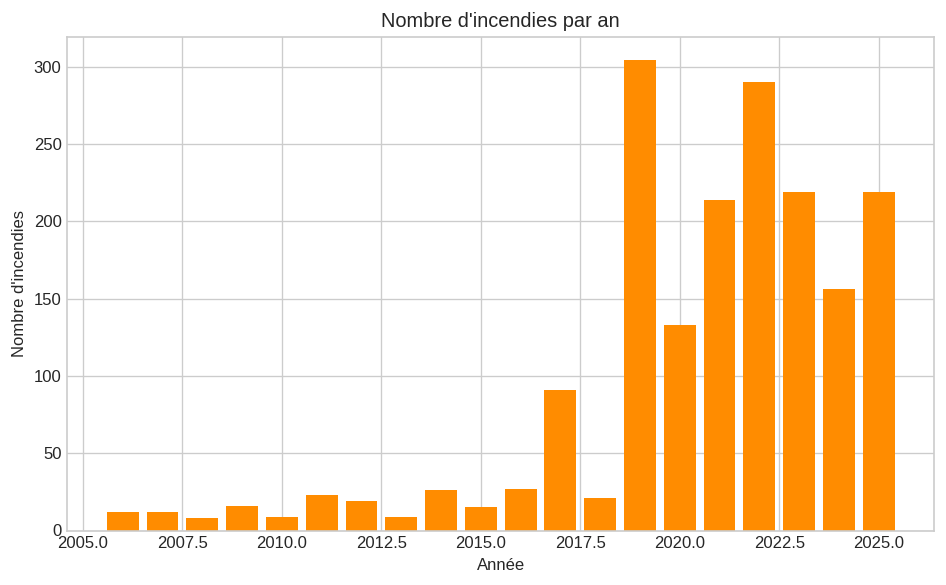

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df["Year"], df["Number_of_Fires"], color="darkorange")
ax.set_title("Nombre d'incendies par an")
ax.set_xlabel("Année")
ax.set_ylabel("Nombre d'incendies")
plt.tight_layout()
plt.savefig("nb_incendies_europe_2006_2025.png", dpi=120)
plt.show()


## Conclusion

Cette analyse des données d'incendies en France entre 2006 et 2025 met en évidence plusieurs constats :

1. **Tendance à la hausse** : la surface brûlée et le nombre d'incendies suivent une trajectoire globalement croissante sur la période, confirmée par la régression linéaire.
2. **Corrélation forte** : le nombre d'incendies et la surface brûlée sont fortement corrélés (r > 0.85), ce qui est attendu, mais le ratio hectares/incendie révèle que certaines années (2019, 2022) se distinguent par des incendies individuellement plus destructeurs plutôt que simplement plus nombreux.
3. **Variabilité interannuelle marquée** : le R² modéré de la régression suggère que des facteurs conjoncturels (conditions météorologiques, sécheresse) jouent un rôle important en plus de la tendance de fond.

Ces résultats pourraient être approfondis en croisant ces données avec des indicateurs climatiques (température, précipitations) pour mieux isoler l'effet du changement climatique de la variabilité naturelle d'une année sur l'autre.